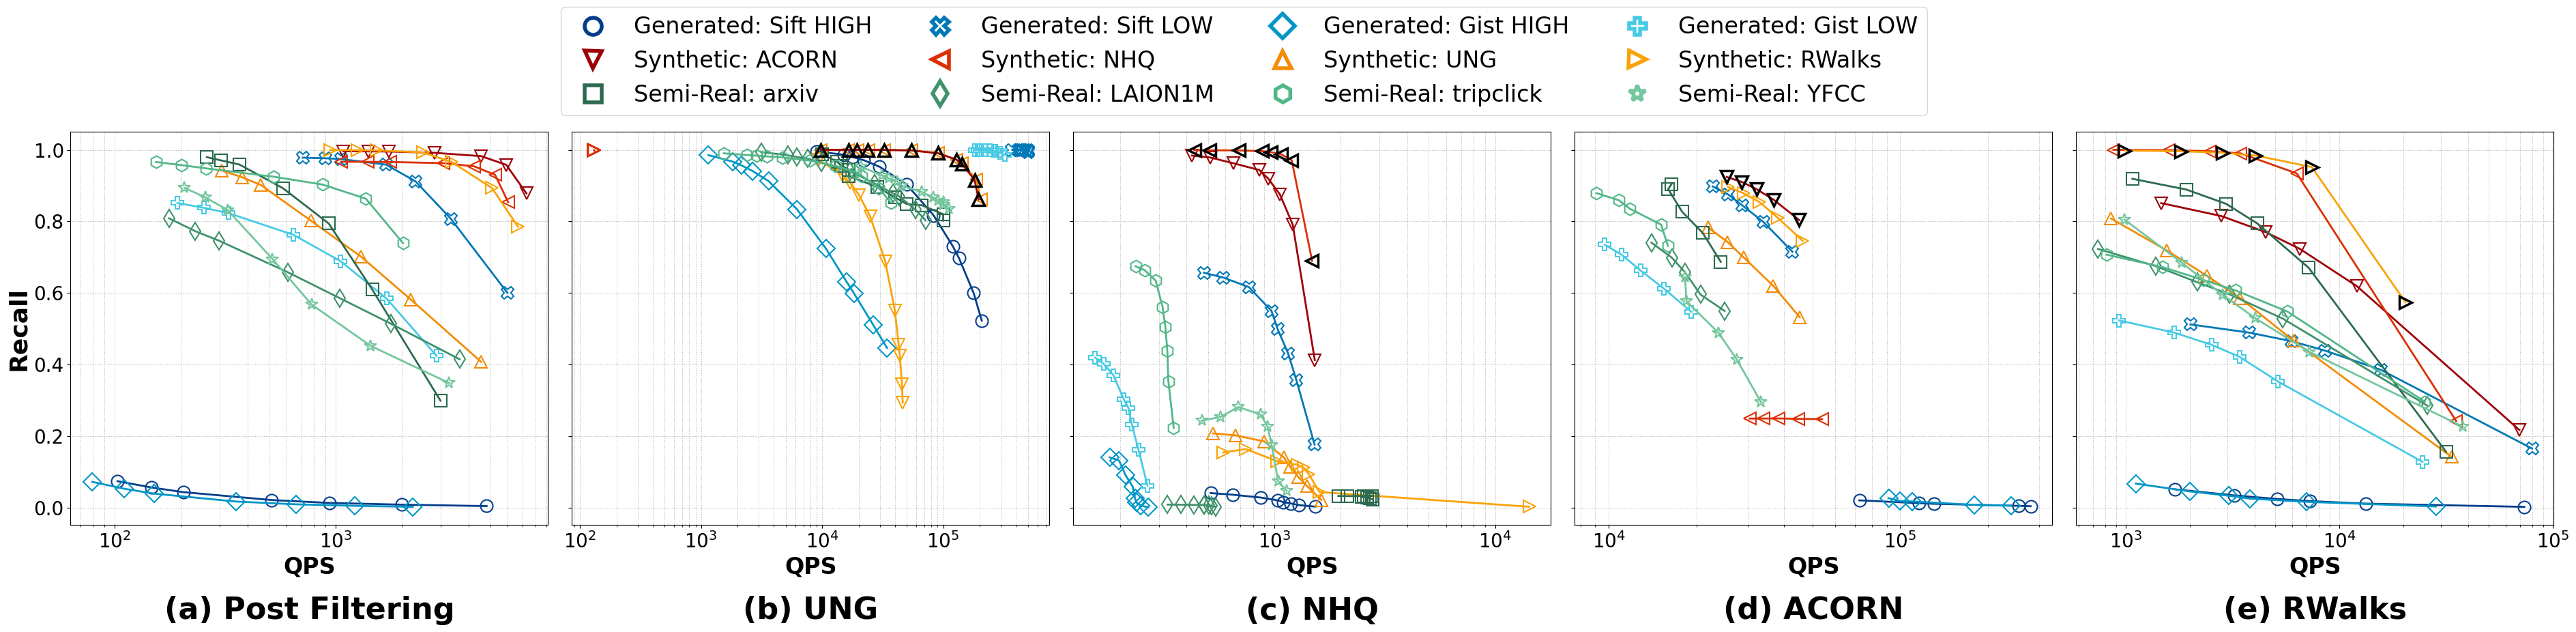

In [2]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1) 데이터셋 클래스 정의
# -----------------------------
GENERATOR_KEYS = {"sift_high", "sift_low", "gist_high", "gist_low"}
SYNTH_KEYS     = {"sift1m_ACORN", "sift1m_UNG", "sift1m_NHQ", "sift1m_RWalks"}
# 나머지는 모두 semi-real

# -----------------------------
# 2) 라인 스타일 (선 두께/마커 크기만 클래스별로 관리)
# -----------------------------
STYLE_BY_CLASS = {
    "generator": {"linestyle": "-", "linewidth": 2, "markersize": 13},
    "synthetic": {"linestyle": "-", "linewidth": 2, "markersize": 13},
    "semi":      {"linestyle": "-", "linewidth": 2, "markersize": 13},
}

# -----------------------------
# 3) dataset_key → label 매핑
# -----------------------------
LABEL_MAP = {
    "sift_high":      "Generated: Sift HIGH",
    "sift_low":       "Generated: Sift LOW",
    "gist_low":       "Generated: Gist LOW",
    "gist_high":      "Generated: Gist HIGH",

    "sift1m_UNG":     "Synthetic: UNG",
    "sift1m_RWalks":  "Synthetic: RWalks",
    "sift1m_NHQ":     "Synthetic: NHQ",
    "sift1m_ACORN":   "Synthetic: ACORN",

    "arxiv":          "Semi-Real: arxiv",
    "LAION1M":        "Semi-Real: LAION1M",
    "tripclick":      "Semi-Real: tripclick",
    "yfcc":           "Semi-Real: YFCC",
}

# -----------------------------
# 4) 클래스별 CVD-safe 색 팔레트
# -----------------------------
# COLOR_BY_CLASS = {
#     "generator": ["#56B4E9", "#A0CBE8", "#0072B2", "#4C72B0"],   # blue 계열
#     "synthetic": ["#E69F00", "#F28E2B", "#EDC948", "#D55E00"],  # orange/yellow 계열
#     "semi":      ["#009E73", "#76B7B2", "#4DAF4A", "#8ED1C6"],  # green/teal 계열
# }

COLOR_BY_CLASS = {
    "generator": ["#023E8A", "#0077B6", "#0096C7", "#48CAE4"],
    "synthetic": ["#9D0208", "#DC2F02", "#F48C06", "#FAA307"],
    "semi":      ["#2D6A4F", "#40916C", "#52B788", "#74C69D"],
}


# -----------------------------
# 5) 마커 리스트: 각 데이터셋마다 다른 모양
# -----------------------------
MARKER_LIST = [
    "d", "s", "D", "P", 
    "v", "<", ">", "^", 
    "o","X","h", "*", ]


# ============================================================
# 0) 여기만 네가 쓰는 pkl / 강조 label / 제목에 맞게 수정하면 됨
#    (예시는 5개 subplot 기준)
# ============================================================
PLOT_CONFIGS = [
    {
        "title": "(a) Post Filtering",
        "pkl_paths": [
            "Post_Filtering_trade_off_result.pkl",
            "Post_Filtering_trade_off_result_semi.pkl",
        ],
        "highlight_labels": set(),   # 강조할 dataset 없으면 빈 set
    },
    {
        
        "title": "(b) UNG",
        "pkl_paths": [
            "UNG_trade_off_result.pkl",
            "UNG_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: UNG"},
    },
    {
        "title": "(c) NHQ",
        "pkl_paths": [
            "NHQ_trade_off_result.pkl",
            "NHQ_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: NHQ"},
    },
    {
        "title": "(d) ACORN",
        "pkl_paths": [
            "ACORN_trade_off_result.pkl",
            "ACORN_trade_off_semi_result.pkl",
        ],
        "highlight_labels": {"Synthetic: ACORN"},
    },
    {
        "title": "(e) RWalks",
        "pkl_paths": [
            "RWalks_trade_off_result.pkl",
            "RWalks_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: RWalks"},
    },
    
]
# 필요 없는 subplot은 CONFIG에서 빼면 됨
# ============================================================


# -----------------------------
# 공통: trade_off 로딩 + marker_map 만들기
#   - 모든 subplot의 key를 다 모아서 marker를 고정
# -----------------------------
all_trade_off = {}      # name -> dict(dataset -> stats)
all_dataset_keys = set()

for cfg in PLOT_CONFIGS:
    merged = {}
    for pkl_name in cfg["pkl_paths"]:
        file_path = os.path.join(".", pkl_name)
        with open(file_path, "rb") as f:
            d = pickle.load(f)
        merged = merged | d      # dict union

    all_trade_off[cfg["title"]] = merged
    all_dataset_keys.update(merged.keys())

# dataset별 marker 고정
marker_map = {}
for idx, dataset_key in enumerate(sorted(all_dataset_keys)):
    marker_map[dataset_key] = MARKER_LIST[idx % len(MARKER_LIST)]


# -----------------------------
#  dataset을 generator / synthetic / semi로 그룹핑
# -----------------------------
def group_keys(trade_off_dict):
    generator_keys = [k for k in trade_off_dict.keys() if k in GENERATOR_KEYS]
    synthetic_keys = [k for k in trade_off_dict.keys() if k in SYNTH_KEYS]
    semi_keys      = [k for k in trade_off_dict.keys()
                      if k not in GENERATOR_KEYS | SYNTH_KEYS]
    return {
        "generator": generator_keys,
        "synthetic": synthetic_keys,
        "semi":      semi_keys,
    }


# -----------------------------
#  서브플롯 생성 (1행 N열)
# -----------------------------
num_plots = len(PLOT_CONFIGS)
fig, axes = plt.subplots(
    1, num_plots,
    figsize=(8 * num_plots, 8),
    sharey=True
)

if num_plots == 1:
    axes = [axes]  # 일관성 유지

# legend는 첫 번째 subplot에서만 label을 받는다
for ax_idx, (ax, cfg) in enumerate(zip(axes, PLOT_CONFIGS)):
    title = cfg["title"]
    trade_off = all_trade_off[title]
    highlight_labels = cfg["highlight_labels"]

    groups = group_keys(trade_off)

    for cls, keys in groups.items():
        base_style = STYLE_BY_CLASS[cls]
        color_list = COLOR_BY_CLASS[cls]

        for local_idx, dataset_key in enumerate(keys):
            stats_dict = trade_off[dataset_key]
            label = LABEL_MAP.get(dataset_key, dataset_key)

            style = base_style.copy()
            color = color_list[local_idx % len(color_list)]
            marker = marker_map.get(dataset_key, "o")

            markerfacecolor = "none"

            # --- 각 subplot별 강조 라인 (검은 테두리) ---
            if label in highlight_labels:
                markeredgecolor = "black"
                markeredgewidth = 2.5
                z = 10
            else:
                markeredgecolor = color
                markeredgewidth = 1.5
                z = 5

            K_ns = sorted(stats_dict.keys(), key=lambda x: x)
            qps_values    = [stats_dict[k]["qps"]        for k in K_ns]
            recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

            # legend는 첫 subplot에서만 label 사용, 나머지는 None
            plot_label = label if ax_idx == 0 else None

            ax.plot(
                qps_values,
                recall_values,
                marker=marker,
                markersize=style["markersize"],
                markerfacecolor=markerfacecolor,
                markeredgecolor=markeredgecolor,
                markeredgewidth=markeredgewidth,
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                color=color,
                label=plot_label,
                zorder=z,
            )

    ax.set_xscale("log")
    ax.set_xlabel("QPS", fontsize=24, fontweight="bold")
    if ax_idx == 0:
        ax.set_ylabel("Recall", fontsize=26, fontweight="bold")
    # ax.set_title(title, fontsize=28, fontweight="bold")
    # --- 제목을 아래로 이동 ---
    ax.text(
        0.5, -0.18,     # 필요하면 -0.25, -0.30 등 조정
        title,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=32,
        fontweight='bold'
    )


    ax.grid(True, which="both", linestyle=":", linewidth=0.7)
    ax.tick_params(axis="both", labelsize=20)

# 공통 Y축 이름이 필요하면 여기에 추가로 써도 됨

# -----------------------------
# 공통 Legend (전체 figure에 하나)
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

from matplotlib.lines import Line2D

# -----------------------------
# 공통 Legend (전체 figure에 하나) — 컬럼 우선(열→행) 3열 4행
# -----------------------------
# 1) 원래 핸들 생성 (지금 코드 그대로)
legend_handles = []
added = set()

for cls, keys in group_keys(all_trade_off[PLOT_CONFIGS[0]["title"]]).items():
    color_list = COLOR_BY_CLASS[cls]

    for local_idx, dataset_key in enumerate(keys):
        label = LABEL_MAP.get(dataset_key, dataset_key)
        color = color_list[local_idx % len(color_list)]
        marker = marker_map.get(dataset_key, "o")

        if label not in added:
            h = Line2D(
                [], [], 
                marker=marker,
                linestyle="",
                markerfacecolor="none",
                markeredgecolor=color,  # legend에서는 검정 테두리 X
                markeredgewidth=4.0,
                markersize=18,
                color=color,
                label=label,
            )
            legend_handles.append(h)
            added.add(label)

legend_labels = [h.get_label() for h in legend_handles]

# 2) 3열 4행 그리드로 재배열해서 "열→행" 순서로 flatten
rows, cols = 3, 4   # 4행 3열

# (필요 시) 그리드 크기에 맞도록 패딩
N = len(legend_handles)
if N < rows * cols:
    pad_n = rows * cols - N
    legend_handles = legend_handles + [None] * pad_n
    legend_labels  = legend_labels  + [None] * pad_n

reordered_handles = []
reordered_labels  = []

# column-major 순서: col 0의 row 0..rows-1 → col 1 → col 2 ...
for c in range(cols):
    for r in range(rows):
        idx = r * cols + c
        h = legend_handles[idx]
        lab = legend_labels[idx]
        if h is not None and lab is not None:
            reordered_handles.append(h)
            reordered_labels.append(lab)

# 3) legend 생성
fig.legend(
    reordered_handles,
    reordered_labels,
    fontsize=24,
    ncol=cols,                 # 3열
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
)



plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.18,
    wspace=0.05,
)

plt.savefig("UNG_multi_subplot.pdf")
plt.show()


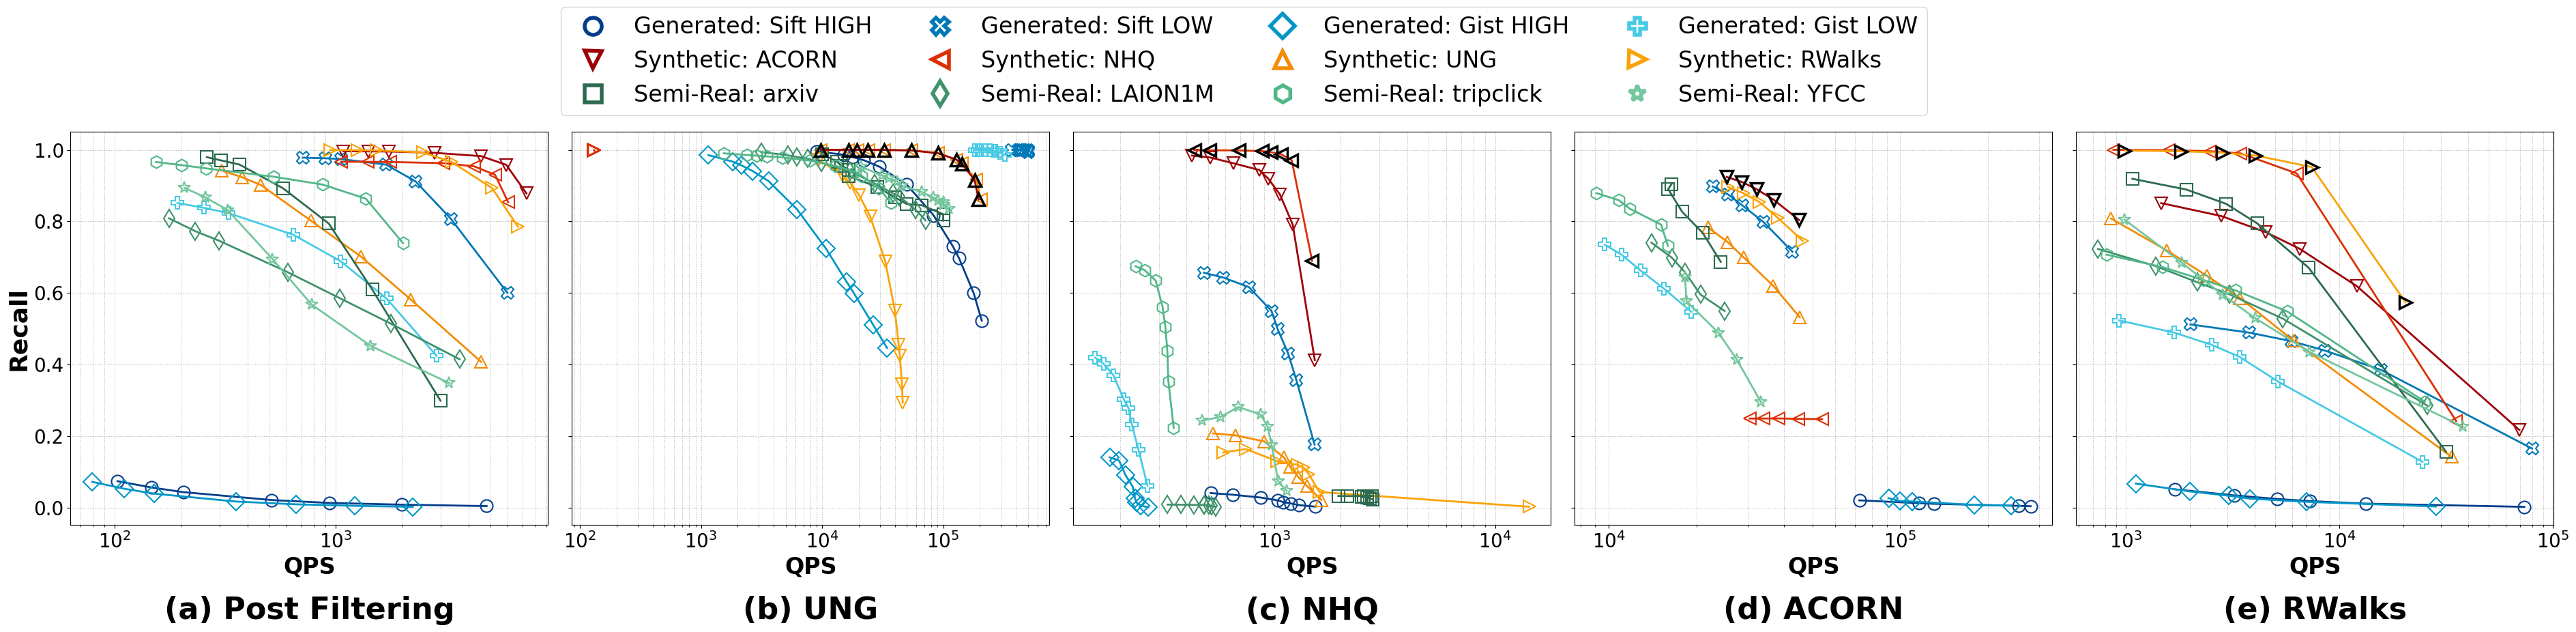

In [63]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1) 데이터셋 클래스 정의
# -----------------------------
GENERATOR_KEYS = {"sift_high", "sift_low", "gist_high", "gist_low"}
SYNTH_KEYS     = {"sift1m_ACORN", "sift1m_UNG", "sift1m_NHQ", "sift1m_RWalks"}
# 나머지는 모두 semi-real

# -----------------------------
# 2) 라인 스타일 (선 두께/마커 크기만 클래스별로 관리)
# -----------------------------
STYLE_BY_CLASS = {
    "generator": {"linestyle": "-", "linewidth": 2, "markersize": 13},
    "synthetic": {"linestyle": "-", "linewidth": 2, "markersize": 13},
    "semi":      {"linestyle": "-", "linewidth": 2, "markersize": 13},
}

# -----------------------------
# 3) dataset_key → label 매핑
# -----------------------------
LABEL_MAP = {
    "sift_high":      "Generated: Sift HIGH",
    "sift_low":       "Generated: Sift LOW",
    "gist_low":       "Generated: Gist LOW",
    "gist_high":      "Generated: Gist HIGH",

    "sift1m_UNG":     "Synthetic: UNG",
    "sift1m_RWalks":  "Synthetic: RWalks",
    "sift1m_NHQ":     "Synthetic: NHQ",
    "sift1m_ACORN":   "Synthetic: ACORN",

    "arxiv":          "Semi-Real: arxiv",
    "LAION1M":        "Semi-Real: LAION1M",
    "tripclick":      "Semi-Real: tripclick",
    "yfcc":           "Semi-Real: YFCC",
}

# -----------------------------
# 4) 클래스별 CVD-safe 색 팔레트
# -----------------------------
# COLOR_BY_CLASS = {
#     "generator": ["#56B4E9", "#A0CBE8", "#0072B2", "#4C72B0"],   # blue 계열
#     "synthetic": ["#E69F00", "#F28E2B", "#EDC948", "#D55E00"],  # orange/yellow 계열
#     "semi":      ["#009E73", "#76B7B2", "#4DAF4A", "#8ED1C6"],  # green/teal 계열
# }
COLOR_BY_CLASS = {
    "generator": ["#023E8A", "#0077B6", "#0096C7", "#48CAE4"],
    "synthetic": ["#9D0208", "#DC2F02", "#F48C06", "#FAA307"],
    "semi":      ["#2D6A4F", "#40916C", "#52B788", "#74C69D"],
}



# -----------------------------
# 5) 마커 리스트: 각 데이터셋마다 다른 모양
# -----------------------------
MARKER_LIST = [
    "d", "s", "D", "P", 
    "v", "<", ">", "^", 
    "o","X","h", "*", ]


# ============================================================
# 0) 여기만 네가 쓰는 pkl / 강조 label / 제목에 맞게 수정하면 됨
#    (예시는 5개 subplot 기준)
# ============================================================
PLOT_CONFIGS = [
    {
        "title": "(a) Post Filtering",
        "pkl_paths": [
            "Post_Filtering_trade_off_result.pkl",
            "Post_Filtering_trade_off_result_semi.pkl",
        ],
        "highlight_labels": set(),   # 강조할 dataset 없으면 빈 set
    },
    {
        
        "title": "(b) UNG",
        "pkl_paths": [
            "UNG_trade_off_result.pkl",
            "UNG_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: UNG"},
    },
    {
        "title": "(c) NHQ",
        "pkl_paths": [
            "NHQ_trade_off_result.pkl",
            "NHQ_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: NHQ"},
    },
    {
        "title": "(d) ACORN",
        "pkl_paths": [
            "ACORN_trade_off_result.pkl",
            "ACORN_trade_off_semi_result.pkl",
        ],
        "highlight_labels": {"Synthetic: ACORN"},
    },
    {
        "title": "(e) RWalks",
        "pkl_paths": [
            "RWalks_trade_off_result.pkl",
            "RWalks_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: RWalks"},
    },
    
]
# 필요 없는 subplot은 CONFIG에서 빼면 됨
# ============================================================


# -----------------------------
# 공통: trade_off 로딩 + marker_map 만들기
#   - 모든 subplot의 key를 다 모아서 marker를 고정
# -----------------------------
all_trade_off = {}      # name -> dict(dataset -> stats)
all_dataset_keys = set()

for cfg in PLOT_CONFIGS:
    merged = {}
    for pkl_name in cfg["pkl_paths"]:
        file_path = os.path.join(".", pkl_name)
        with open(file_path, "rb") as f:
            d = pickle.load(f)
        merged = merged | d      # dict union

    all_trade_off[cfg["title"]] = merged
    all_dataset_keys.update(merged.keys())

# dataset별 marker 고정
marker_map = {}
for idx, dataset_key in enumerate(sorted(all_dataset_keys)):
    marker_map[dataset_key] = MARKER_LIST[idx % len(MARKER_LIST)]


# -----------------------------
#  dataset을 generator / synthetic / semi로 그룹핑
# -----------------------------
def group_keys(trade_off_dict):
    generator_keys = [k for k in trade_off_dict.keys() if k in GENERATOR_KEYS]
    synthetic_keys = [k for k in trade_off_dict.keys() if k in SYNTH_KEYS]
    semi_keys      = [k for k in trade_off_dict.keys()
                      if k not in GENERATOR_KEYS | SYNTH_KEYS]
    return {
        "generator": generator_keys,
        "synthetic": synthetic_keys,
        "semi":      semi_keys,
    }


# -----------------------------
#  서브플롯 생성 (1행 N열)
# -----------------------------
num_plots = len(PLOT_CONFIGS)
fig, axes = plt.subplots(
    1, num_plots,
    figsize=(8 * num_plots, 8),
    sharey=True
)

if num_plots == 1:
    axes = [axes]  # 일관성 유지

# legend는 첫 번째 subplot에서만 label을 받는다
for ax_idx, (ax, cfg) in enumerate(zip(axes, PLOT_CONFIGS)):
    title = cfg["title"]
    trade_off = all_trade_off[title]
    highlight_labels = cfg["highlight_labels"]

    groups = group_keys(trade_off)

    for cls, keys in groups.items():
        base_style = STYLE_BY_CLASS[cls]
        color_list = COLOR_BY_CLASS[cls]

        for local_idx, dataset_key in enumerate(keys):
            stats_dict = trade_off[dataset_key]
            label = LABEL_MAP.get(dataset_key, dataset_key)

            style = base_style.copy()
            color = color_list[local_idx % len(color_list)]
            marker = marker_map.get(dataset_key, "o")

            markerfacecolor = "none"

            # --- 각 subplot별 강조 라인 (검은 테두리) ---
            if label in highlight_labels:
                markeredgecolor = "black"
                markeredgewidth = 2.5
                z = 10
            else:
                markeredgecolor = color
                markeredgewidth = 1.5
                z = 5

            K_ns = sorted(stats_dict.keys(), key=lambda x: x)
            qps_values    = [stats_dict[k]["qps"]        for k in K_ns]
            recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

            # legend는 첫 subplot에서만 label 사용, 나머지는 None
            plot_label = label if ax_idx == 0 else None

            ax.plot(
                qps_values,
                recall_values,
                marker=marker,
                markersize=style["markersize"],
                markerfacecolor=markerfacecolor,
                markeredgecolor=markeredgecolor,
                markeredgewidth=markeredgewidth,
                linestyle=style["linestyle"],
                linewidth=style["linewidth"],
                color=color,
                label=plot_label,
                zorder=z,
            )

    ax.set_xscale("log")
    ax.set_xlabel("QPS", fontsize=24, fontweight="bold")
    if ax_idx == 0:
        ax.set_ylabel("Recall", fontsize=26, fontweight="bold")
    # ax.set_title(title, fontsize=28, fontweight="bold")
    # --- 제목을 아래로 이동 ---
    ax.text(
        0.5, -0.18,     # 필요하면 -0.25, -0.30 등 조정
        title,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=32,
        fontweight='bold'
    )


    ax.grid(True, which="both", linestyle=":", linewidth=0.7)
    ax.tick_params(axis="both", labelsize=20)

# 공통 Y축 이름이 필요하면 여기에 추가로 써도 됨

# -----------------------------
# 공통 Legend (전체 figure에 하나)
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

from matplotlib.lines import Line2D

# -----------------------------
# 공통 Legend (전체 figure에 하나) — 컬럼 우선(열→행) 3열 4행
# -----------------------------
# 1) 원래 핸들 생성 (지금 코드 그대로)
legend_handles = []
added = set()

for cls, keys in group_keys(all_trade_off[PLOT_CONFIGS[0]["title"]]).items():
    color_list = COLOR_BY_CLASS[cls]

    for local_idx, dataset_key in enumerate(keys):
        label = LABEL_MAP.get(dataset_key, dataset_key)
        color = color_list[local_idx % len(color_list)]
        marker = marker_map.get(dataset_key, "o")

        if label not in added:
            h = Line2D(
                [], [], 
                marker=marker,
                linestyle="",
                markerfacecolor="none",
                markeredgecolor=color,  # legend에서는 검정 테두리 X
                markeredgewidth=4.0,
                markersize=18,
                color=color,
                label=label,
            )
            legend_handles.append(h)
            added.add(label)

legend_labels = [h.get_label() for h in legend_handles]

# 2) 3열 4행 그리드로 재배열해서 "열→행" 순서로 flatten
rows, cols = 3, 4   # 4행 3열

# (필요 시) 그리드 크기에 맞도록 패딩
N = len(legend_handles)
if N < rows * cols:
    pad_n = rows * cols - N
    legend_handles = legend_handles + [None] * pad_n
    legend_labels  = legend_labels  + [None] * pad_n

reordered_handles = []
reordered_labels  = []

# column-major 순서: col 0의 row 0..rows-1 → col 1 → col 2 ...
for c in range(cols):
    for r in range(rows):
        idx = r * cols + c
        h = legend_handles[idx]
        lab = legend_labels[idx]
        if h is not None and lab is not None:
            reordered_handles.append(h)
            reordered_labels.append(lab)

# 3) legend 생성
fig.legend(
    reordered_handles,
    reordered_labels,
    fontsize=24,
    ncol=cols,                 # 3열
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
)



plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.18,
    wspace=0.05,
)

plt.savefig("UNG_multi_subplot.pdf")
plt.show()


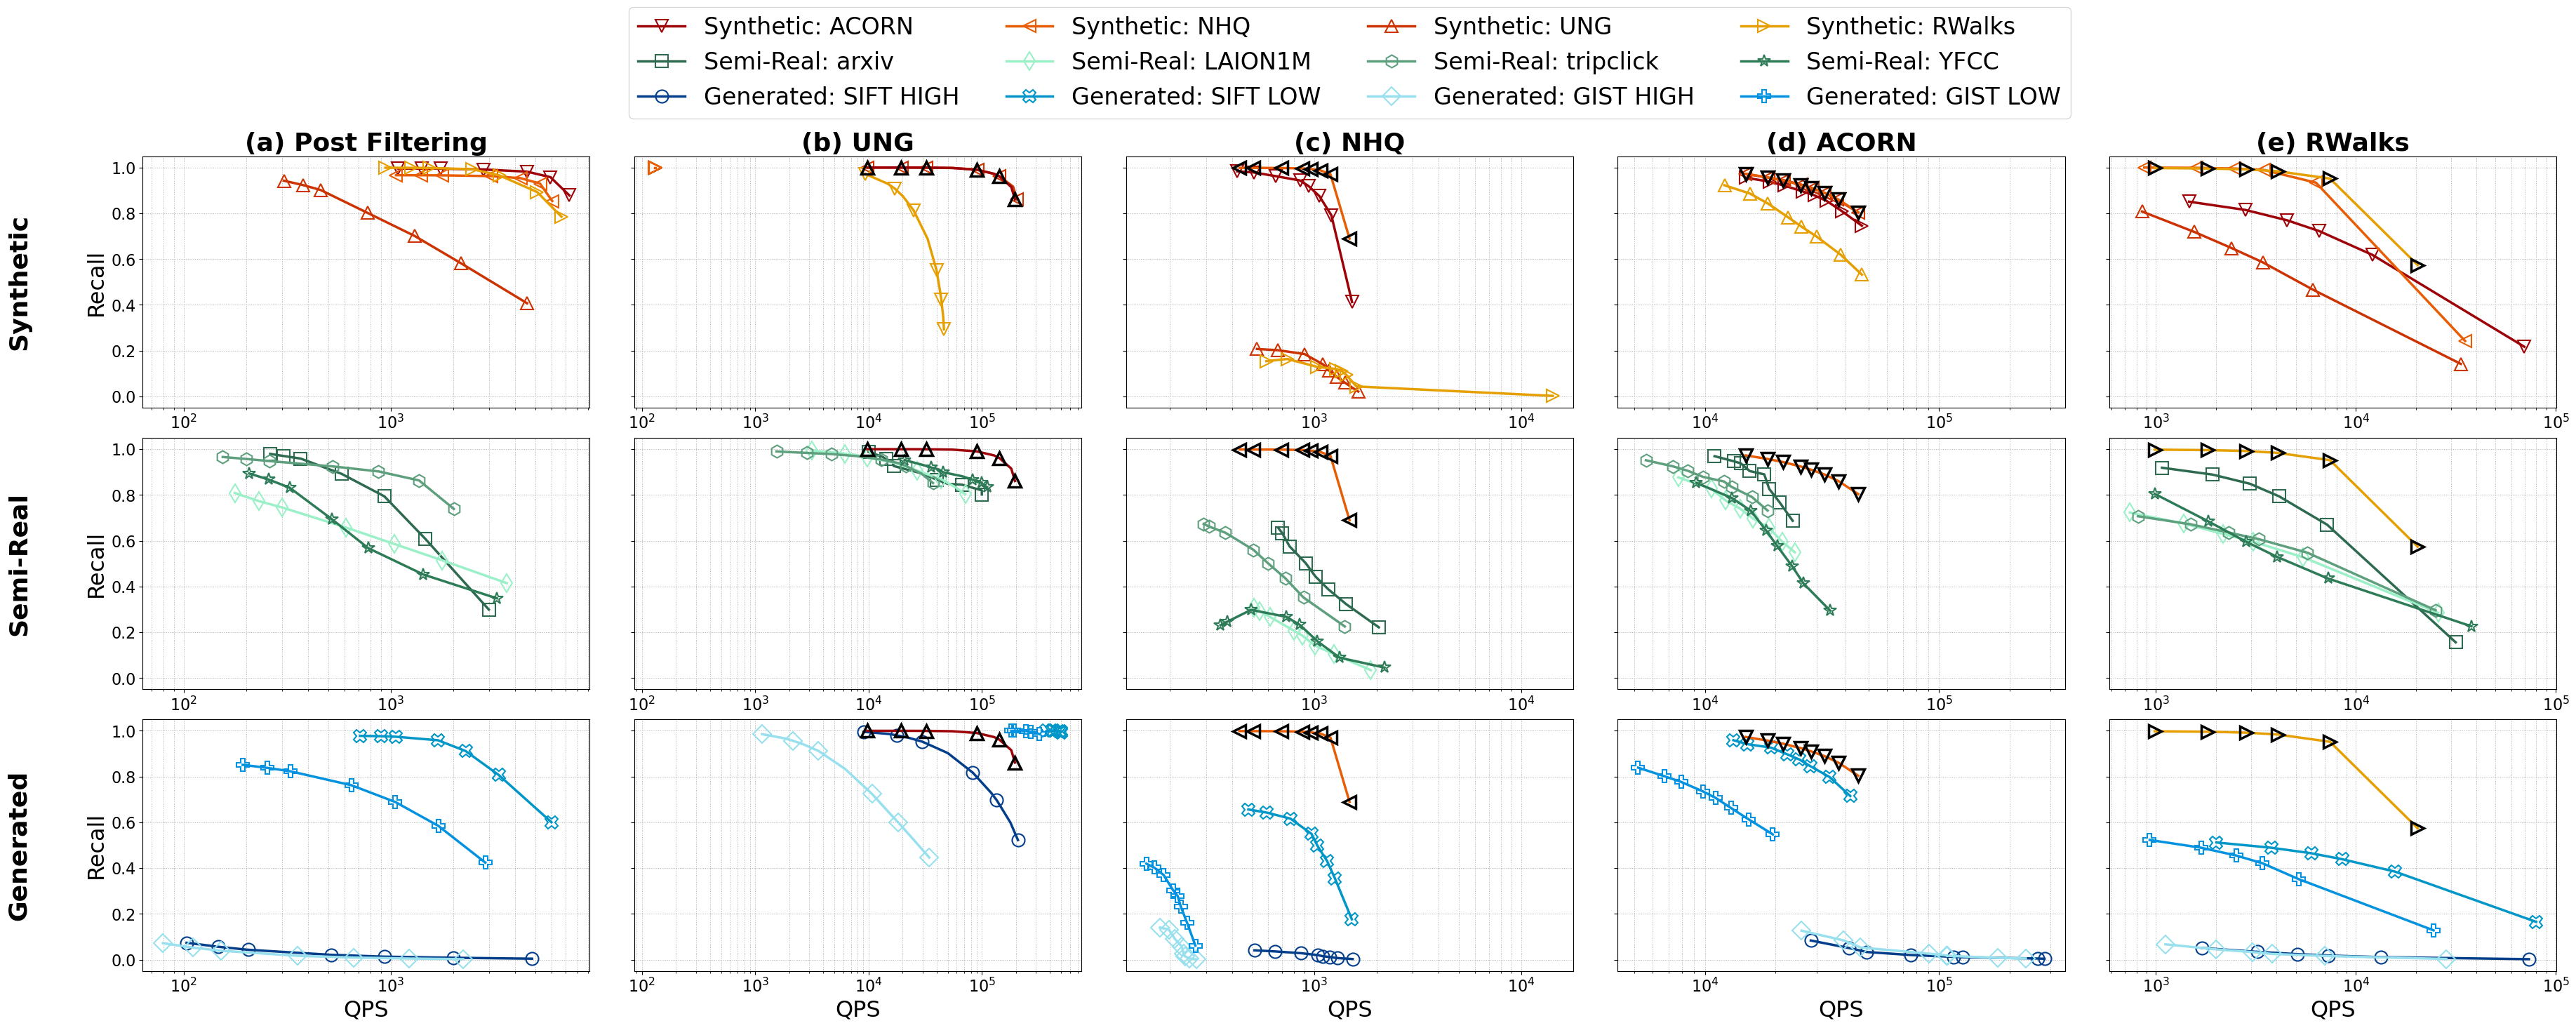

In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# (참고: 아래 미정의 함수들은 실행 환경에 존재하는 것으로 가정합니다.)
# from scipy.stats import ks_2samp
# from scipy.stats import wasserstein_distance

# -----------------------------
# 1) 데이터셋 클래스 정의
# -----------------------------
GENERATOR_KEYS = {"sift_high", "sift_low", "gist_high", "gist_low"}
SYNTH_KEYS     = {"sift1m_ACORN", "sift1m_UNG", "sift1m_NHQ", "sift1m_RWalks"}
# 나머지는 모두 semi-real

# -----------------------------
# 2) 라인 스타일
# -----------------------------
STYLE_BY_CLASS = {
    "generator": {"linestyle": "-", "linewidth": 2.5, "markersize": 13},
    "synthetic": {"linestyle": "-", "linewidth": 2.5, "markersize": 13},
    "semi":      {"linestyle": "-", "linewidth": 2.5, "markersize": 13},
}

# -----------------------------
# 3) dataset_key → label 매핑
# -----------------------------
LABEL_MAP = {
    "sift_high":      "Generated: SIFT HIGH",
    "sift_low":       "Generated: SIFT LOW",
    "gist_low":       "Generated: GIST LOW",
    "gist_high":      "Generated: GIST HIGH",

    "sift1m_UNG":     "Synthetic: UNG",
    "sift1m_RWalks":  "Synthetic: RWalks",
    "sift1m_NHQ":     "Synthetic: NHQ",
    "sift1m_ACORN":   "Synthetic: ACORN",

    "arxiv":          "Semi-Real: arxiv",
    "LAION1M":        "Semi-Real: LAION1M",
    "tripclick":      "Semi-Real: tripclick",
    "yfcc":           "Semi-Real: YFCC",
}

INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

# -----------------------------
# 4) 색 팔레트
# -----------------------------
COLOR_BY_CLASS = {
    "generator": ["#023E8A", "#0096C7", "#98E0EE", "#0292DF",],
    "synthetic": [ "#9D0208", "#E85D04", "#CC3300", "#E69F00",],
    "semi":      ["#2D6A4F",  "#9BF0C8", "#5E9F7E", "#2E7B58"],
}

# -----------------------------
# 5) 마커 리스트
# -----------------------------
MARKER_LIST = ["d", "s", "D", "P", "v", "<", ">", "^", "o", "X", "h", "*"]

# -----------------------------
# 6) 열(메서드)별 설정
# -----------------------------
PLOT_CONFIGS = [
    {
        "title": "(a) Post Filtering",
        "pkl_paths": [
            "Post_Filtering_trade_off_result.pkl",
            "Post_Filtering_trade_off_result_semi.pkl",
        ],
        "highlight_labels": set(),
    },
    {
        "title": "(b) UNG",
        "pkl_paths": [
            "UNG_trade_off_result.pkl",
            "UNG_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: UNG"},
    },
    {
        "title": "(c) NHQ",
        "pkl_paths": [
            "NHQ_trade_off_result.pkl",
            "NHQ_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: NHQ"},
    },
    {
        "title": "(d) ACORN",
        "pkl_paths": [
            "ACORN_trade_off_result.pkl",
            "ACORN_trade_off_semi_result.pkl",
        ],
        "highlight_labels": {"Synthetic: ACORN"},
    },
    {
        "title": "(e) RWalks",
        "pkl_paths": [
            "RWalks_trade_off_result.pkl",
            "RWalks_trade_off_result_semi.pkl",
        ],
        "highlight_labels": {"Synthetic: RWalks"},
    },
]

# -----------------------------
# trade_off 로딩 + marker_map
# -----------------------------
all_trade_off = {}
all_dataset_keys = set()

for cfg in PLOT_CONFIGS:
    merged = {}
    for pkl_name in cfg["pkl_paths"]:
        # 파일이 실제로 존재한다고 가정하고 로드
        if os.path.exists(pkl_name):
            try:
                with open(pkl_name, "rb") as f:
                    d = pickle.load(f)
                merged = merged | d
            except Exception as e:
                print(f"Error loading {pkl_name}: {e}")
        else:
            print(f"Warning: {pkl_name} not found. Skipping.")
            
    all_trade_off[cfg["title"]] = merged
    all_dataset_keys.update(merged.keys())

marker_map = {
    dataset_key: MARKER_LIST[idx % len(MARKER_LIST)]
    for idx, dataset_key in enumerate(sorted(all_dataset_keys))
}

# -----------------------------
# grouping
# -----------------------------
def group_keys(trade_off_dict):
    generator_keys = [k for k in trade_off_dict if k in GENERATOR_KEYS]
    synthetic_keys = [k for k in trade_off_dict if k in SYNTH_KEYS]
    semi_keys      = [k for k in trade_off_dict
                      if k not in GENERATOR_KEYS | SYNTH_KEYS]
    return {
        "synthetic": synthetic_keys,
        "semi":      semi_keys,
        "generator": generator_keys,
    }

class_order = ["synthetic", "semi", "generator"]
row_titles  = ["Synthetic", "Semi-Real", "Generated"]

num_rows = len(class_order)   # 3
num_cols = len(PLOT_CONFIGS)  # 5

# --- 핵심 수정: sharex='col' 추가 ---
fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols,
    figsize=(8 * num_cols, 4.5 * num_rows),
    sharey=True,
    sharex='col' # 같은 컬럼 내 차트들이 x축을 공유하도록 설정
)
# ------------------------------------

if num_rows == 1:
    axes = np.array([axes])

# -----------------------------
# main loop: col = method, row = class
# -----------------------------
for col_idx, cfg in enumerate(PLOT_CONFIGS):
    method_title = cfg["title"]
    trade_off    = all_trade_off[method_title]
    groups       = group_keys(trade_off)

    highlight_keys = {
        INV_LABEL_MAP[lbl]
        for lbl in cfg["highlight_labels"]
        if lbl in INV_LABEL_MAP
    }

    # UNG 열이면 markevery 적용
    markevery_val = 2 if method_title == "(b) UNG" else None

    # --- 각 하이라이트 데이터셋의 "원래 색"을 이 컬럼에서 한 번만 계산 ---
    highlight_color_map = {}
    for hk in highlight_keys:
        # hk가 실제로 속한 class(row)를 찾는다
        for cls0 in class_order:
            class_keys0 = groups[cls0]
            if hk in class_keys0:
                palette = COLOR_BY_CLASS[cls0]
                idx_in_class = class_keys0.index(hk)
                highlight_color_map[hk] = palette[idx_in_class % len(palette)]
                break

    for row_idx, cls in enumerate(class_order):
        ax = axes[row_idx, col_idx]

        base_style = STYLE_BY_CLASS[cls]
        color_list = COLOR_BY_CLASS[cls]
        class_keys = groups[cls]

        # 1) highlight 라인 (모든 row 에서 동일 색으로)
        for hk in highlight_keys:
            if hk not in trade_off:
                continue

            stats_dict = trade_off[hk]
            Ks = sorted(stats_dict.keys(), key=lambda x: x)
            qps_values    = [stats_dict[k]["qps"]        for k in Ks]
            recall_values = [stats_dict[k]["avg_recall"] for k in Ks]

            marker = marker_map.get(hk, "o")
            label  = LABEL_MAP.get(hk, hk)

            # legend는 첫 번째 열에서만
            plot_label = label if col_idx == 0 else None

            # 이 컬럼에서 미리 계산해 둔 "원래 색" 사용
            highlight_color = highlight_color_map.get(hk, color_list[0])

            ax.plot(
                qps_values,
                recall_values,
                marker=marker,
                markersize=base_style["markersize"],
                markerfacecolor="none",
                markeredgecolor="black",
                markeredgewidth=2.5,
                linestyle=base_style["linestyle"],
                linewidth=base_style["linewidth"],
                color=highlight_color,           # 컬럼 내에서 모든 row 동일
                label=plot_label,
                zorder=15,
                markevery=markevery_val,
            )

        # 2) 해당 class의 나머지 라인들
        for local_idx, dataset_key in enumerate(class_keys):
            if dataset_key in highlight_keys:
                continue

            stats_dict = trade_off[dataset_key]
            Ks = sorted(stats_dict.keys(), key=lambda x: x)
            qps_values    = [stats_dict[k]["qps"]        for k in Ks]
            recall_values = [stats_dict[k]["avg_recall"] for k in Ks]

            marker = marker_map.get(dataset_key, "o")
            label  = LABEL_MAP.get(dataset_key, dataset_key)

            color = color_list[local_idx % len(color_list)]

            plot_label = label if col_idx == 0 else None

            ax.plot(
                qps_values,
                recall_values,
                marker=marker,
                markersize=base_style["markersize"],
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.5,
                linestyle=base_style["linestyle"],
                linewidth=base_style["linewidth"],
                color=color,
                label=plot_label,
                zorder=5,
                markevery=markevery_val,
            )

        # 축 설정
        ax.set_xscale("log")
        ax.grid(True, which="both", linestyle=":", linewidth=0.7)
        ax.tick_params(axis="both", labelsize=16)

        # 맨 위 행에 method 제목
        if row_idx == 0:
            ax.set_title(method_title, fontsize=26, fontweight="bold")

        # 맨 왼쪽 열에 class 제목 + y label
        if col_idx == 0:
            ax.set_ylabel("Recall", fontsize=23)
            ax.text(
                -0.25, 0.5,
                row_titles[row_idx],
                transform=ax.transAxes,
                ha='right',
                va='center',
                fontsize=26,
                fontweight='bold',
                rotation="vertical"
            )

        # 맨 아래 행에 x label
        if row_idx == num_rows - 1:
            ax.set_xlabel("QPS", fontsize=23)

        ax.tick_params(axis="x", labelbottom=True)

# -----------------------------
# Legend: row-major → col-major 로 재배열
# -----------------------------
all_handles = []
all_labels  = []
seen = set()

# 우선 기존 방식대로 전부 수집 (row/col 상관없이)
for ax in axes.ravel():
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll and ll not in seen:
            all_handles.append(hh)
            all_labels.append(ll)
            seen.add(ll)

legend_handles = all_handles
legend_labels  = all_labels

# 3x4 그리드 가정 (데이터셋 12개라면 딱 맞음)
rows, cols = 3, 4   # 3행 4열 (레전드에 표시할 행/열 수)

N = len(legend_handles)
if N < rows * cols:
    pad_n = rows * cols - N
    # None 대신 빈 Line2D 객체를 사용하여 레전드에 빈 칸을 만듭니다.
    empty_handle = Line2D([0], [0], color='w', marker='None', linestyle='None')
    legend_handles = legend_handles + [empty_handle] * pad_n
    legend_labels  = legend_labels  + [''] * pad_n

reordered_handles = []
reordered_labels  = []

# ★ col-major 순서: col 0의 row 0..rows-1 → col 1 → col 2 ...
for c in range(cols):
    for r in range(rows):
        idx = r * cols + c     # row-major 인덱스를 col-major 순회로 읽기
        h = legend_handles[idx]
        lab = legend_labels[idx]
        
        reordered_handles.append(h)
        reordered_labels.append(lab)

# legend 생성 (열 수 = cols)
fig.legend(
    reordered_handles,
    reordered_labels,
    fontsize=24,
    ncol=cols,
    bbox_to_anchor=(0.55, 1.10),
    loc="upper center",
)

# -----------------------------
# 서브플롯 간격 좁게 조정
# -----------------------------
plt.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.93,
    bottom=0.07,
    wspace=0.10,
    hspace=0.12,
)

# -----------------------------
# 저장 및 출력 (실제 실행은 주석 처리)
# -----------------------------
plt.savefig(".pdf")
plt.show()

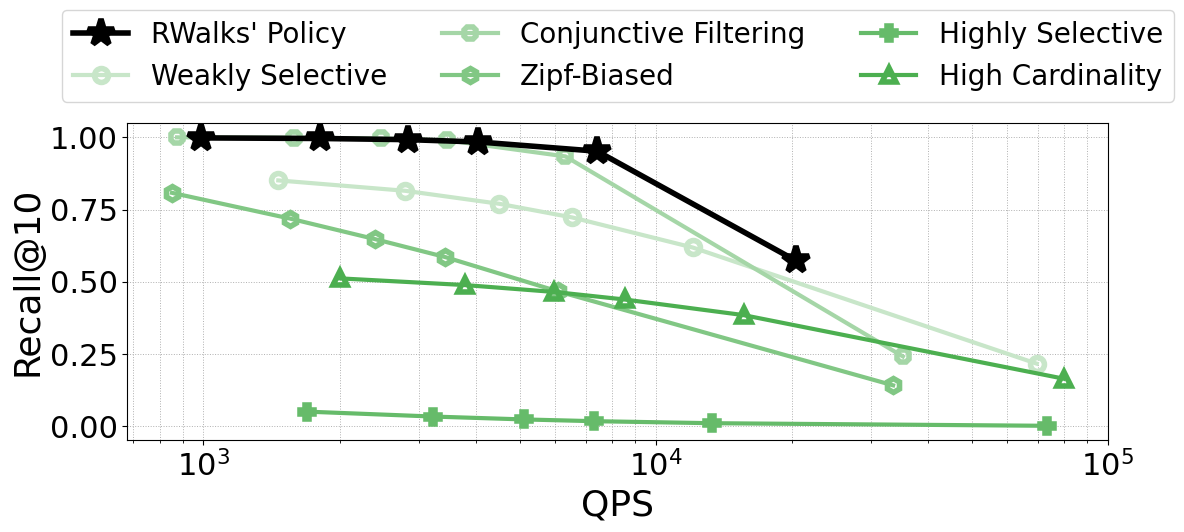

In [39]:
import os
import pickle
import matplotlib.pyplot as plt

# -----------------------------
# 1) 표시할 데이터셋 선택 (여기만 바꾸면 됨)
# -----------------------------
DATASETS_TO_PLOT = [
    # Generated
    # "sift_high", "sift_low", "gist_high", "gist_low",
    "sift_high", "sift_low",

    # Synthetic
    "sift1m_RWalks", "sift1m_ACORN", "sift1m_NHQ", "sift1m_UNG",

    # Semi-real
    # "arxiv", "LAION1M", "tripclick", "yfcc",
    # "arxiv", "tripclick"
]

# -----------------------------
# 2) RWalks 결과 pkl 경로
#    - 너 환경에 맞게 파일명만 맞춰주면 됨
# -----------------------------
PKL_PATHS = [
    "RWalks_trade_off_result.pkl",
    "RWalks_trade_off_result_semi.pkl",
]

# -----------------------------
# 3) 분류 키 / 라벨 / 스타일
# -----------------------------
GENERATOR_KEYS = {"sift_high", "sift_low", "gist_high", "gist_low"}
SYNTH_KEYS     = {"sift1m_ACORN", "sift1m_UNG", "sift1m_NHQ", "sift1m_RWalks"}

LABEL_MAP = {
    "sift_high":     "Highly Selective",
    "sift_low":      "High Cardinality",
    "gist_high":     "Generated: GIST High",
    "gist_low":      "Generated: GIST Low",
    "sift1m_RWalks": "RWalks' Policy",
    "sift1m_ACORN":  "Weakly Selective",
    "sift1m_NHQ":    "Conjunctive Filtering",
    "sift1m_UNG":    "Zipf-Biased",
    "arxiv":         "Semi-Real: arXiv",
    "LAION1M":       "Semi-Real: LAION1M",
    "tripclick":     "Semi-Real: TripClick",
    "yfcc":          "Semi-Real: YFCC",
}

# class별 팔레트(필요 최소만)
colors = [
    "#E3F2FD", "#BBDEFB", "#90CAF9", "#64B5F6", "#42A5F5",
    "#2196F3", "#1E88E5", "#1976D2", "#1565C0", "#0D47A1"
]
colors = [
    "#E8F5E9", "#C8E6C9", "#A5D6A7", "#81C784", "#66BB6A",
    "#4CAF50", "#43A047", "#388E3C", "#2E7D32", "#1B5E20"
]


COLOR_BY_CLASS = {
    "synthetic":  ["#000000", colors[1],colors[2],colors[3]],
    "semi":       ["red", "#5E9F7E", "#9BF0C8", "#2E7B58"],
    "generator":  [colors[4], colors[5], "#98E0EE", "#0292DF"],
}

MARKERS = ["*", "o", "8", "h", "P", "^", "X", "h", "*", "<", ">", "d"]

def get_class(dataset_key: str) -> str:
    if dataset_key in GENERATOR_KEYS:
        return "generator"
    if dataset_key in SYNTH_KEYS:
        return "synthetic"
    return "semi"

# -----------------------------
# 4) pkl 로드 (여러 파일 병합)
# -----------------------------
def load_tradeoff_dict(pkl_paths):
    merged = {}
    for p in pkl_paths:
        if not os.path.exists(p):
            print(f"[WARN] not found: {p}")
            continue
        try:
            with open(p, "rb") as f:
                d = pickle.load(f)
            # 파이썬 3.9+ 기준 dict union 가능하지만, 안전하게 update 사용
            merged.update(d)
        except Exception as e:
            print(f"[ERROR] loading {p}: {e}")
    return merged

trade_off = load_tradeoff_dict(PKL_PATHS)

# -----------------------------
# 5) 실제로 그릴 데이터셋만 필터링
# -----------------------------
to_plot = [k for k in DATASETS_TO_PLOT if k in trade_off]
missing = [k for k in DATASETS_TO_PLOT if k not in trade_off]
if missing:
    print("[WARN] missing keys (not in loaded pkl):")
    for k in missing:
        print("  -", k)

# class별로 묶어서 같은 계열끼리 색 순서를 자연스럽게
grouped = {"synthetic": [], "semi": [], "generator": []}
for k in to_plot:
    grouped[get_class(k)].append(k)

# -----------------------------
# 6) Plot
# -----------------------------
plt.figure(figsize=(12, 6))

marker_idx = 0
for cls in ["synthetic", "semi", "generator"]:
    keys = grouped[cls]
    palette = COLOR_BY_CLASS[cls]
    for i, dataset_key in enumerate(keys):
        stats = trade_off[dataset_key]
        Ks = sorted(stats.keys())
        qps = [stats[k]["qps"] for k in Ks]
        recall = [stats[k]["avg_recall"] for k in Ks]

        color = palette[i % len(palette)]
        marker = MARKERS[marker_idx % len(MARKERS)]
        marker_idx += 1
        if dataset_key == "sift1m_RWalks":
            plt.plot(
            qps, recall,
            label=LABEL_MAP.get(dataset_key, dataset_key),
            color=color,
            linewidth=4,
            marker=marker,
            markersize=20,
            # markerfacecolor="none",
            markeredgewidth=4,
            zorder= 5
        )
        else:
            plt.plot(
                qps, recall,
                label=LABEL_MAP.get(dataset_key, dataset_key),
                color=color,
                linewidth=3,
                marker=marker,
                markersize=10,
                markerfacecolor="none",
                markeredgewidth=4,
            )

plt.xscale("log")
plt.xlabel("QPS", fontsize=26)
plt.ylabel("Recall@10", fontsize=26)
plt.tick_params(axis="both", labelsize=22)
# plt.title("Recall–QPS Trade-off (RWalks)", fontsize=16, fontweight="bold")
plt.grid(True, which="both", linestyle=":", linewidth=0.7)

plt.legend(
    fontsize=20,
    ncol=3,          # 1 row로 만들기 (항목 수만큼 열)
    loc="upper center",
    bbox_to_anchor=(0.5, 1.4), # 차트 위로 올리기
    # frameon=False               # (논문용이면 보통 frame 제거)
)

plt.tight_layout()

# 저장 경로는 네가 지정
plt.savefig("rwalks_tradeoff_modi.pdf", dpi=300)
plt.show()


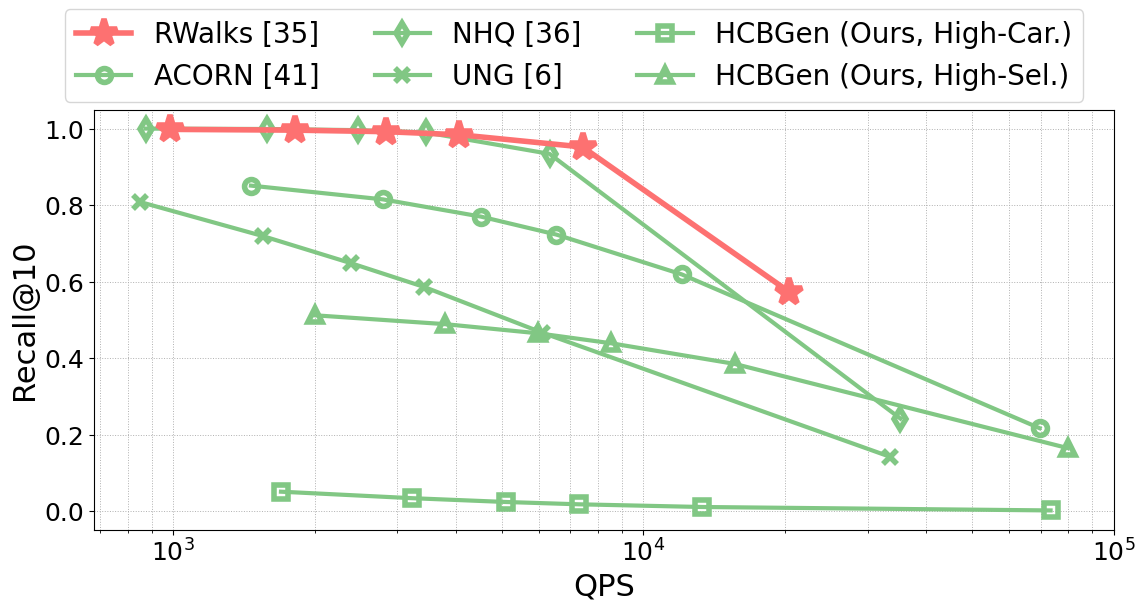

[Saved] rwalks_tradeoff_modi_fixed.pdf


In [47]:
import os
import pickle
import matplotlib.pyplot as plt

# -----------------------------
# 1) 표시할 데이터셋 선택 (여기만 바꾸면 됨)
# -----------------------------
DATASETS_TO_PLOT = [
    # Generated
    "sift_high", "sift_low",

    # Synthetic
    "sift1m_RWalks", "sift1m_ACORN", "sift1m_NHQ", "sift1m_UNG",
]

# -----------------------------
# 2) RWalks 결과 pkl 경로
# -----------------------------
PKL_PATHS = [
    "RWalks_trade_off_result.pkl",
    "RWalks_trade_off_result_semi.pkl",
]

# -----------------------------
# 3) 분류 키 / 라벨 / 스타일
# -----------------------------
GENERATOR_KEYS = {"sift_high", "sift_low", "gist_high", "gist_low"}
SYNTH_KEYS     = {"sift1m_ACORN", "sift1m_UNG", "sift1m_NHQ", "sift1m_RWalks"}

LABEL_MAP = {
    "sift_high":     "HCBGen (Ours, High-Car.)",
    "sift_low":      "HCBGen (Ours, High-Sel.)",
    "gist_high":     "Generated: GIST High",
    "gist_low":      "Generated: GIST Low",
    "sift1m_RWalks": "RWalks [35]",
    "sift1m_ACORN":  "ACORN [41]",
    "sift1m_NHQ":    "NHQ [36]",
    "sift1m_UNG":    "UNG [6]",
    "arxiv":         "Semi-Real: arXiv",
    "LAION1M":       "Semi-Real: LAION1M",
    "tripclick":     "Semi-Real: TripClick",
    "yfcc":          "Semi-Real: YFCC",
}

# class별 팔레트
colors = [
    "#E8F5E9", "#C8E6C9", "#A5D6A7", "#81C784", "#66BB6A",
    "#4CAF50", "#43A047", "#388E3C", "#2E7D32", "#1B5E20"
]

COLOR_BY_CLASS = {
    "synthetic":  ["#FD7171", colors[3], colors[3], colors[3]],
    "semi":       ["red", "#5E9F7E", "#9BF0C8", "#2E7B58"],
    "generator":  [colors[3], colors[3], "#98E0EE", "#0292DF"],
}

MARKERS = ["*", "o", "d", "x", "s", "^", "X", "h", "*", "<", ">", "d"]

def get_class(dataset_key: str) -> str:
    if dataset_key in GENERATOR_KEYS:
        return "generator"
    if dataset_key in SYNTH_KEYS:
        return "synthetic"
    return "semi"

# -----------------------------
# 4) pkl 로드 (여러 파일 병합)
# -----------------------------
def load_tradeoff_dict(pkl_paths):
    merged = {}
    for p in pkl_paths:
        if not os.path.exists(p):
            print(f"[WARN] not found: {p}")
            continue
        try:
            with open(p, "rb") as f:
                d = pickle.load(f)
            merged.update(d)
        except Exception as e:
            print(f"[ERROR] loading {p}: {e}")
    return merged

trade_off = load_tradeoff_dict(PKL_PATHS)

# -----------------------------
# 5) 실제로 그릴 데이터셋만 필터링
# -----------------------------
to_plot = [k for k in DATASETS_TO_PLOT if k in trade_off]
missing = [k for k in DATASETS_TO_PLOT if k not in trade_off]
if missing:
    print("[WARN] missing keys (not in loaded pkl):")
    for k in missing:
        print("  -", k)

grouped = {"synthetic": [], "semi": [], "generator": []}
for k in to_plot:
    grouped[get_class(k)].append(k)

# -----------------------------
# 6) Figure & Axes (add_axes로 축 크기 고정)
# -----------------------------
fig = plt.figure(figsize=(12, 6))

# [left, bottom, width, height] in figure coordinates (0~1)
ax = fig.add_axes([0.10, 0.16, 0.85, 0.70])

# -----------------------------
# 7) Plot
# -----------------------------
marker_idx = 0
for cls in ["synthetic", "semi", "generator"]:
    keys = grouped[cls]
    palette = COLOR_BY_CLASS[cls]
    for i, dataset_key in enumerate(keys):
        stats = trade_off[dataset_key]
        Ks = sorted(stats.keys())
        qps = [stats[k]["qps"] for k in Ks]
        recall = [stats[k]["avg_recall"] for k in Ks]

        color = palette[i % len(palette)]
        marker = MARKERS[marker_idx % len(MARKERS)]
        marker_idx += 1

        if dataset_key == "sift1m_RWalks":
            ax.plot(
                qps, recall,
                label=LABEL_MAP.get(dataset_key, dataset_key),
                color=color,
                linewidth=4,
                marker=marker,
                markersize=20,
                markeredgewidth=4,
                zorder=5
            )
        else:
            ax.plot(
                qps, recall,
                label=LABEL_MAP.get(dataset_key, dataset_key),
                color=color,
                linewidth=3,
                marker=marker,
                markersize=10,
                markerfacecolor="none",
                markeredgewidth=4,
            )

ax.set_xscale("log")
ax.set_xlabel("QPS", fontsize=22)
ax.set_ylabel("Recall@10", fontsize=22)
ax.tick_params(axis="both", labelsize=18)
ax.grid(True, which="both", linestyle=":", linewidth=0.7)

# -----------------------------
# 8) Legend (figure 기준으로 밖에 배치)
# -----------------------------
fig.legend(
    fontsize=20,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
)

# -----------------------------
# 9) Save
# -----------------------------
out_path = "rwalks_tradeoff_modi_fixed.pdf"
plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
plt.show()
print(f"[Saved] {out_path}")


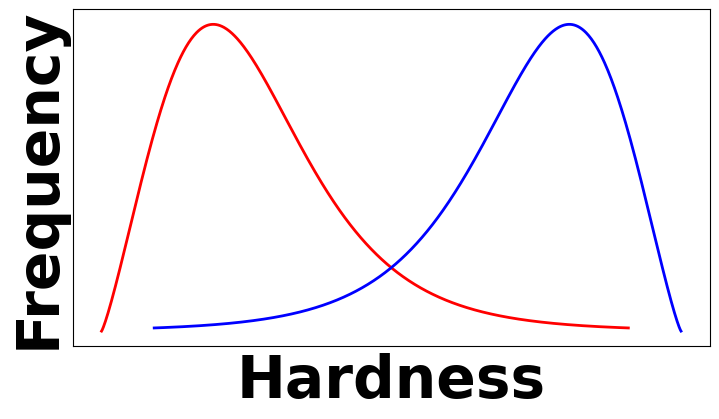

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import burr12

# ----------------------------
# 예쁜 heavy-tail 분포 생성 (Burr XII)
# ----------------------------
np.random.seed(0)

n = 20000

# 모양 튜닝 파라미터 (이 값들이 대체로 "사진 느낌" 잘 나옴)
c = 2.2      # 1보다 크면 원점에서 pdf가 0으로 시작하는 쪽으로 감
d = 3.0
scale = 1.0

x = burr12.rvs(c, d, scale=scale, size=n)

# 너무 긴 꼬리 때문에 그림이 망가지면 상위 일부만 컷 (시각화용)
x = x[x <= np.percentile(x, 99.5)]

# ----------------------------
# Plot: histogram + true PDF
# ----------------------------
plt.figure(figsize=(7, 4))

# 파란 히스토그램 (Density)
# plt.hist(x, bins=12, density=True, alpha=0.6, edgecolor="black")

# 빨간 곡선 (이론 PDF)
xs = np.linspace(0, x.max(), 800)
plt.plot(xs, burr12.pdf(xs, c, d, scale=scale), color="red", linewidth=2)

xs = np.linspace(0, x.max(), 800)
plt.plot(1.1* x.max() -xs, burr12.pdf(xs, c, d, scale=scale), color="blue", linewidth=2)

plt.xlabel("Hardness", fontsize=42, fontweight="bold")
plt.ylabel("Frequency", fontsize=42, fontweight="bold")
# ✅ 축 숫자 제거
plt.xticks([])
plt.yticks([])
plt.axis("on")
plt.tight_layout(pad=0)
plt.savefig("hardness_mirrored.pdf", format="pdf", bbox_inches="tight")


plt.show()

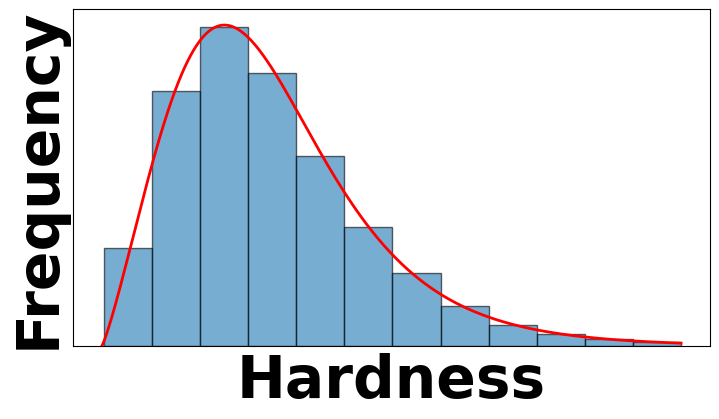

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import burr12

# ----------------------------
# 예쁜 heavy-tail 분포 생성 (Burr XII)
# ----------------------------
np.random.seed(0)

n = 20000

# 모양 튜닝 파라미터 (이 값들이 대체로 "사진 느낌" 잘 나옴)
c = 2.2      # 1보다 크면 원점에서 pdf가 0으로 시작하는 쪽으로 감
d = 3.0
scale = 1.0

x = burr12.rvs(c, d, scale=scale, size=n)

# 너무 긴 꼬리 때문에 그림이 망가지면 상위 일부만 컷 (시각화용)
x = x[x <= np.percentile(x, 99.5)]

# ----------------------------
# Plot: histogram + true PDF
# ----------------------------
plt.figure(figsize=(7, 4))

# 파란 히스토그램 (Density)
plt.hist(x, bins=12, density=True, alpha=0.6, edgecolor="black")

# 빨간 곡선 (이론 PDF)
xs = np.linspace(0, x.max(), 800)
plt.plot(xs, burr12.pdf(xs, c, d, scale=scale), color="red", linewidth=2)

plt.xlabel("Hardness", fontsize=42, fontweight="bold")
plt.ylabel("Frequency", fontsize=42, fontweight="bold")
# ✅ 축 숫자 제거
plt.xticks([])
plt.yticks([])
plt.axis("on")
plt.tight_layout(pad=0)
plt.savefig("bin_why.pdf", format="pdf", bbox_inches="tight")
plt.show()